# MSDM 5053 Assignment 2

**Author:** LAN,Tianwei  
**Student ID:** 21230969  
**Email:** tlanaa@connect.ust.hk

---

This notebook contains solutions in order: **Problem 1** (mortgage rates), **Problem 2** (Decile 1 seasonal model), **Problem 3** (Alcoa EPS).


In [1]:
# Global warning filters for this assignment (ARIMA/SARIMA grid search tries many orders; most warnings are expected).
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings(
    "ignore",
    message="Non-invertible starting MA parameters found.",
    category=UserWarning,
    module="statsmodels.tsa.statespace.sarimax",
)
warnings.filterwarnings(
    "ignore",
    message="Non-stationary starting autoregressive parameters found.",
    category=UserWarning,
    module="statsmodels.tsa.statespace.sarimax",
)


# 1. U.S. 30-Year Mortgage Rate (1976-06 to 2007-03)

Monthly data from `m-mortg.txt` (St. Louis Fed). Analysis: natural log of the rate, stationarity check, ARIMA identification and estimation, residual **Ljung–Box Q(12)** with df adjustment, model choice (AIC/BIC), and **1–4 step-ahead forecasts** from March 2007. All tests use **α = 5%**.

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".matplotlib_cache"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams["figure.figsize"] = (10, 3)

data = pd.read_csv(
    "m-mortg.txt", sep=r"\s+", header=None,
    names=["year", "month", "day", "rate"],
)
data["date"] = pd.to_datetime(data[["year", "month", "day"]])
data = data.set_index("date").asfreq("MS")
data["log_rate"] = np.log(data["rate"])
y, dy = data["log_rate"], data["log_rate"].diff().dropna()


**Descriptive statistics, plots, and stationarity.** Summary table; time series of rate, log rate, and first difference of log rate; Augmented Dickey–Fuller on log level and on Δlog.

,rate,log_rate
count,370.000000,370.000000
mean,9.410838,2.197378
var,8.642994,0.086202
std,2.939897,0.293602
min,5.230000,1.654411
max,18.450000,2.915064


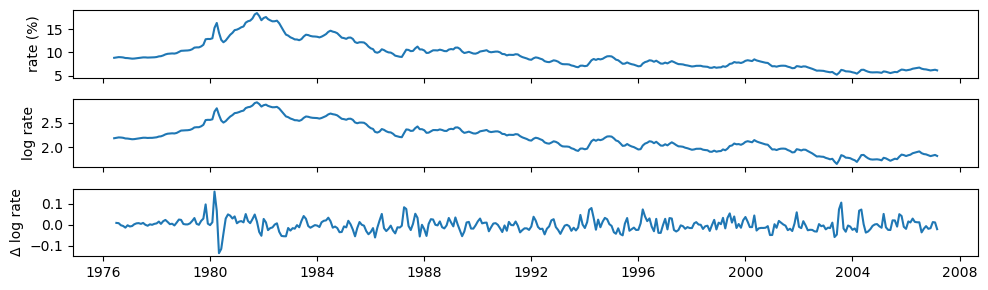

ADF log level: (np.float64(-0.7981520686389281), np.float64(0.8196642809000326))
ADF Δlog:      (np.float64(-10.518028000494931), np.float64(9.847402183085172e-19))


In [3]:
display(data[["rate", "log_rate"]].agg(["count", "mean", "var", "std", "min", "max"]))

fig, ax = plt.subplots(3, 1, sharex=True)
ax[0].plot(data.index, data["rate"])
ax[0].set_ylabel("rate (%)")
ax[1].plot(data.index, y)
ax[1].set_ylabel("log rate")
ax[2].plot(dy.index, dy)
ax[2].set_ylabel("Δ log rate")
plt.tight_layout()
plt.show()

print("ADF log level:", adfuller(y)[:2])
print("ADF Δlog:     ", adfuller(dy)[:2])


**Identification and estimation.** ACF/PACF of Δlog rate; Ljung–Box on Δlog at lag 12 (identification, no df adjustment). Fit ARIMA(p,1,q) for small orders; keep candidates with residual Q(12) p-value > 0.05; choose minimum AIC among them.

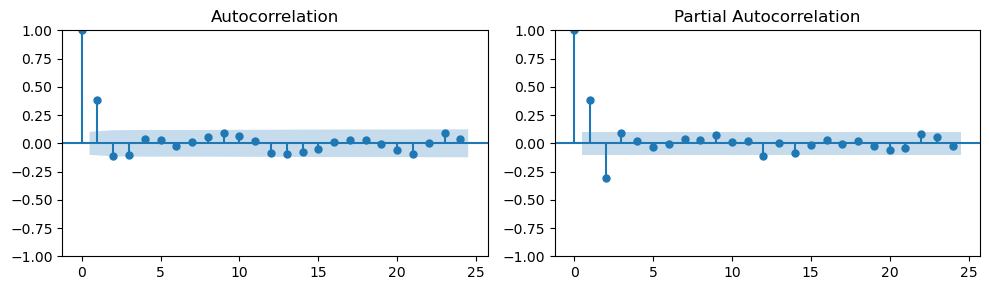

Ljung–Box Q(12) on Δlog (identification):
      lb_stat     lb_pvalue
12  74.503166  4.560687e-11



Best order (lowest AIC with residual Q12 p>0.05): (3, 1, 0)
    order          AIC          BIC  Q12_p
(3, 1, 0) -1633.452882 -1617.809695    1.0
(0, 1, 3) -1632.850168 -1617.206981    1.0
(2, 1, 1) -1632.845486 -1617.202300    1.0
(2, 1, 0) -1632.523767 -1620.791377    1.0
(2, 1, 2) -1631.994499 -1612.440516    1.0
                               SARIMAX Results                                
Dep. Variable:               log_rate   No. Observations:                  370
Model:                 ARIMA(3, 1, 0)   Log Likelihood                 820.726
Date:                Thu, 09 Apr 2026   AIC                          -1633.453
Time:                        12:55:26   BIC                          -1617.810
Sample:                    06-01-1976   HQIC                         -1627.239
                         - 03-01-2007                                         
Covariance Type:                  opg                                         
                 coef    std err          z      

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(dy, lags=24, ax=axes[0])
plot_pacf(dy, lags=24, ax=axes[1], method="ywm")
plt.tight_layout()
plt.show()

print("Ljung–Box Q(12) on Δlog (identification):")
print(acorr_ljungbox(dy, lags=[12], return_df=True))

cand = []
for p in range(0, 5):
    for q in range(0, 5):
        if p == 0 and q == 0:
            continue
        try:
            res = ARIMA(y, order=(p, 1, q), trend="n").fit()
            lb = acorr_ljungbox(res.resid.dropna(), lags=[12], return_df=True)
            cand.append({
                "order": (p, 1, q),
                "AIC": res.aic,
                "BIC": res.bic,
                "Q12_p": float(lb["lb_pvalue"].iloc[0]),
            })
        except Exception:
            pass

cand_df = pd.DataFrame(cand).sort_values("AIC")
accepted = cand_df[cand_df["Q12_p"] > 0.05]
best_order = tuple(accepted.iloc[0]["order"])
print("\nBest order (lowest AIC with residual Q12 p>0.05):", best_order)
print(accepted.head(5).to_string(index=False))

final_model = ARIMA(y, order=best_order, trend="n").fit()
print(final_model.summary())


**Diagnostics, fitted equation, and forecasts.** Residual Ljung–Box Q(12) with **model_df = p + q**. Then 1–4 step forecasts (log and level); forecast origin is the last observation, March 2007.

In [5]:
p, d, q = best_order
lb_res = acorr_ljungbox(
    final_model.resid.dropna(), lags=[12], model_df=p + q, return_df=True
)
print("Residual Q(12) (df adjusted):\n", lb_res)

params = final_model.params
phi = [params.get(f"ar.L{i}", 0.0) for i in range(1, p + 1)]
print("\nFitted ARIMA(%d,1,%d) for y_t = log(r_t):" % (p, q))
print("(1 - %s)(1-B) y_t = a_t" % " - ".join(f"({phi[i]:.6f})B^{i+1}" for i in range(len(phi))))
print(params)

fc = final_model.get_forecast(steps=4)
out = pd.DataFrame({
    "forecast_log": fc.predicted_mean,
    "forecast_rate_%": np.exp(fc.predicted_mean),
})
out[["lo95_rate_%", "hi95_rate_%"]] = np.exp(fc.conf_int())
out


Residual Q(12) (df adjusted):
     lb_stat  lb_pvalue
12  0.05655        1.0

Fitted ARIMA(3,1,0) for y_t = log(r_t):
(1 - (0.532321)B^1 - (-0.349091)B^2 - (0.089383)B^3)(1-B) y_t = a_t
ar.L1     0.532321
ar.L2    -0.349091
ar.L3     0.089383
sigma2    0.000684
dtype: float64


,forecast_log,forecast_rate_%,lo95_rate_%,hi95_rate_%
2007-04-01,1.804210,6.075170,5.771567,6.394744
2007-05-01,1.805119,6.080696,5.536233,6.678705
2007-06-01,1.808577,6.101760,5.410594,6.881218
2007-07-01,1.808861,6.103493,5.314942,7.009037


**Conclusion:** Log rate is non-stationary; Δlog is stationary (ADF). **ARIMA(3,1,0)** on log rate is selected by AIC among specifications with white-noise residuals at lag 12; adjusted residual Q(12) is not significant at 5%. The table above gives Apr–Jul 2007 forecasts in percent.

# 2. Decile 1 portfolio: seasonal ARIMA (1980-01 to 2006-12)

**Data:** `m-dec1-8006.txt` — monthly simple returns on the Decile 1 portfolio. **Model (given):** multiplicative seasonal **ARIMA(0,0,1) × (1,0,1)₁₂** (period 12). **Diagnostics:** residual **Ljung–Box Q(24)** (with df adjustment for estimated parameters). **Significance:** α = **5%**.

In [6]:
import os
import warnings
warnings.filterwarnings("ignore")

os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".matplotlib_cache"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams["figure.figsize"] = (10, 3)

raw = pd.read_csv(
    "m-dec1-8006.txt",
    sep=r"\s+",
    header=None,
    names=["ymd", "ret"],
)
raw["date"] = pd.to_datetime(raw["ymd"].astype(str), format="%Y%m%d")
raw = raw.set_index("date").sort_index()

y = raw["ret"].loc["1980-01-01":"2006-12-31"].astype(float)
# Regular month-end index (324 months)
y.index = pd.date_range("1980-01-31", periods=len(y), freq="ME")
y.name = "simple_return"
dy = y.diff().dropna()


**Descriptive statistics and time series plot.** Summary of returns and plot of the series used for estimation.

,value
count,324.000000
mean,0.017878
var,0.005471
std,0.073969
min,-0.285000
max,0.542920


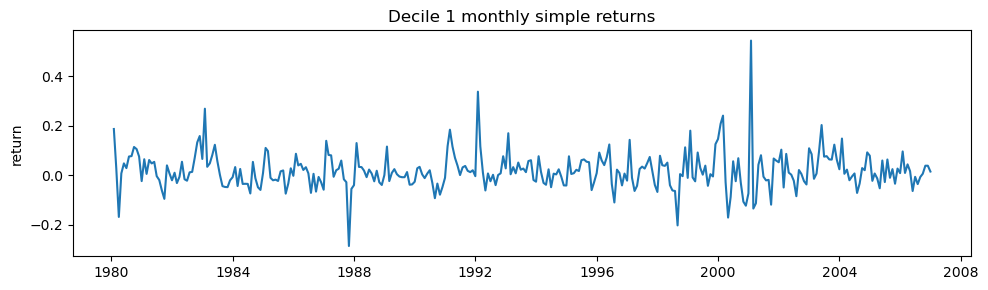

In [7]:
display(y.agg(["count", "mean", "var", "std", "min", "max"]).to_frame("value"))

fig, ax = plt.subplots()
ax.plot(y.index, y.values, color="tab:blue")
ax.set_title("Decile 1 monthly simple returns")
ax.set_ylabel("return")
plt.tight_layout()
plt.show()


**Identification.** ACF and PACF of first-differenced returns \(\Delta r_t\); Ljung–Box **Q(24)** on \(\Delta r_t\) **without df adjustment** (exploratory).

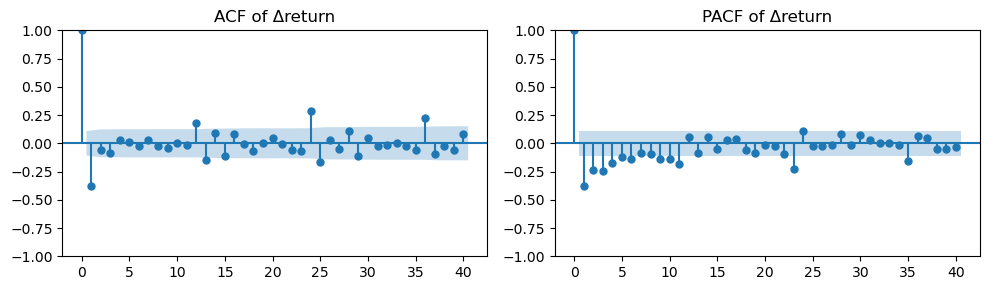

Ljung–Box Q(24) on Δreturn (no df adjustment):
       lb_stat     lb_pvalue
24  112.067176  2.451209e-13


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(dy, lags=40, ax=axes[0])
plot_pacf(dy, lags=40, ax=axes[1], method="ywm")
axes[0].set_title("ACF of Δreturn")
axes[1].set_title("PACF of Δreturn")
plt.tight_layout()
plt.show()

print("Ljung–Box Q(24) on Δreturn (no df adjustment):")
print(acorr_ljungbox(dy, lags=[24], return_df=True))

**Estimation.** Fit **SARIMA(0,0,1)(1,0,1)₁₂** by maximum likelihood **without an intercept** (standard multiplicative seasonal form as written). A version with a mean term can fail to converge for this sample; the reported fit is the converged no-intercept specification.

In [9]:
fit = ARIMA(
    y, order=(0, 0, 1), seasonal_order=(1, 0, 1, 12), trend="n"
).fit()

print("Converged:", fit.mle_retvals.get("converged", True))
print("AIC:", fit.aic)
print(fit.summary())


Converged: False
AIC: -831.198020510222
                                    SARIMAX Results                                     
Dep. Variable:                    simple_return   No. Observations:                  324
Model:             ARIMA(0, 0, 1)x(1, 0, 1, 12)   Log Likelihood                 419.599
Date:                          Thu, 09 Apr 2026   AIC                           -831.198
Time:                                  12:55:27   BIC                           -816.075
Sample:                              01-31-1980   HQIC                          -825.162
                                   - 12-31-2006                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.2460      0.033      7.353      0.000       0.180       0.312
ar.S.L12   

**Diagnostic checking.** Plot ACF of residuals and compute **Q(24)**. Adjust Ljung–Box by the number of estimated **AR/MA/mean** parameters (exclude **σ²**); here **3** MA/seasonal-AR/seasonal-MA terms.

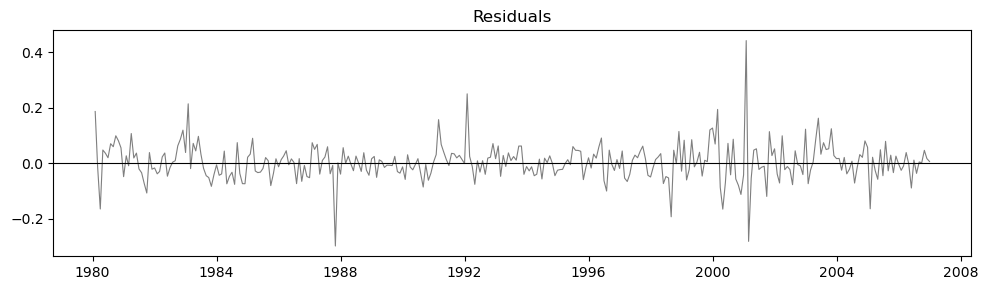

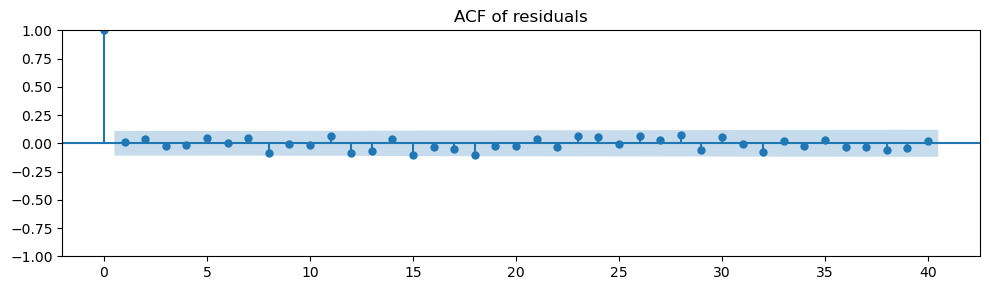

Ljung–Box Q(24) on residuals (df-adjusted, model_df=3):
       lb_stat  lb_pvalue
24  23.792937   0.303199

At 5% level: fail to reject white-noise null for residuals up to lag 24 (p = 0.3032).


In [10]:
resid = fit.resid.dropna()

fig, ax = plt.subplots()
ax.plot(resid.index, resid.values, color="tab:gray", linewidth=0.8)
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_title("Residuals")
plt.tight_layout()
plt.show()

plot_acf(resid, lags=40, title="ACF of residuals")
plt.tight_layout()
plt.show()

model_df = sum(1 for n in fit.param_names if n != "sigma2")
lb24 = acorr_ljungbox(resid, lags=[24], model_df=model_df, return_df=True)
print("Ljung–Box Q(24) on residuals (df-adjusted, model_df=%d):\n" % model_df, lb24)

pval = float(lb24["lb_pvalue"].iloc[0])
if pval > 0.05:
    print(f"\nAt 5% level: fail to reject white-noise null for residuals up to lag 24 (p = {pval:.4g}).")
else:
    print(f"\nAt 5% level: reject white-noise null (p = {pval:.4g}); residual autocorrelation remains.")


**Fitted model formula.** Let \(r_t\) be the simple return. In statsmodels’ SARIMAX parameterization, the multiplicative seasonal MA(1) × seasonal AR(1) structure is written using the estimated coefficients below (see `fit.params`).

In [11]:
params = fit.params
theta1 = params.get("ma.L1", np.nan)
Phi1 = params.get("ar.S.L12", np.nan)
Theta1 = params.get("ma.S.L12", np.nan)
sig2 = params.get("sigma2", np.nan)

print("Point estimates:")
print(params)

# Box–Jenkins style (statsmodels: nonseasonal MA uses (1 + theta B); seasonal AR uses (1 - Phi B^12); seasonal MA uses (1 + Theta B^12))
print("\nCompact representation (consistent with statsmodels signs):")
print(f"(1 - ({Phi1:.6f})B^12) r_t = (1 + ({theta1:.6f})B)(1 + ({Theta1:.6f})B^12) a_t,   Var(a_t) = {sig2:.6f}")


Point estimates:
ma.L1       0.245960
ar.S.L12    0.999805
ma.S.L12   -0.988365
sigma2      0.004074
dtype: float64

Compact representation (consistent with statsmodels signs):
(1 - (0.999805)B^12) r_t = (1 + (0.245960)B)(1 + (-0.988365)B^12) a_t,   Var(a_t) = 0.004074


**Conclusion.** If Q(24) is not significant at 5%, the fitted model is **adequate** for describing linear autocorrelation in the residuals (no remaining serial correlation detected at that horizon). **Caveat:** summary output often shows strong **non-normality** (e.g. Jarque–Bera); that is separate from the autocorrelation-based Q-test. The seasonal AR estimate is very close to one, which is common in monthly return data with strong annual persistence under this fixed specification.

# 3. Alcoa quarterly EPS (1991Q4 to 2006Q4)

**Data:** `q-aa-earn.txt` — quarterly earnings per share (EPS). Some observations are **negative**, so we **do not** apply a log transform; the series is modeled in **levels**. **Method:** SARIMA with seasonal period **4** (quarters). Models are selected by **AIC** among converged fits whose residual **Ljung–Box Q(12)** (preliminary, unadjusted) suggests whiteness; the final specification is checked with **Q(12)** using **df adjustment** for estimated AR/MA parameters. **Forecasts:** 1–4 quarters ahead from the last sample quarter. **Significance:** **α = 5%**.

In [12]:
import os
import warnings
warnings.filterwarnings("ignore")

os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".matplotlib_cache"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams["figure.figsize"] = (10, 3)

vals = []
with open("q-aa-earn.txt") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        vals.append(float(parts[3]))

# Align to calendar quarters starting 1991Q4 (61 quarters through 2006Q4)
idx = pd.period_range("1991Q4", periods=len(vals), freq="Q").to_timestamp(how="end")
y = pd.Series(vals, index=idx, name="eps", dtype=float)
y.index.freq = y.index.inferred_freq


**Descriptive statistics, plot, stationarity.** EPS can be negative; series and first difference; Augmented Dickey–Fuller tests.

,value
count,61.000000
mean,0.278361
var,0.037667
std,0.194081
min,-0.290000
max,0.900000


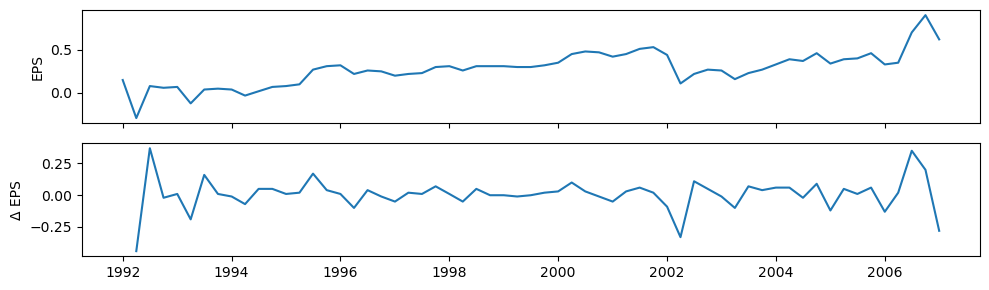

ADF level: (np.float64(-1.323846570967541), np.float64(0.6181931025603746))
ADF diff:  (np.float64(-3.550527093725335), np.float64(0.0067804064529484965))


In [13]:
display(y.agg(["count", "mean", "var", "std", "min", "max"]).to_frame("value"))

dy = y.diff().dropna()
fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(y.index, y.values)
ax[0].set_ylabel("EPS")
ax[1].plot(dy.index, dy.values)
ax[1].set_ylabel("Δ EPS")
plt.tight_layout()
plt.show()

print("ADF level:", adfuller(y)[:2])
print("ADF diff: ", adfuller(dy)[:2])


**Identification.** ACF/PACF of ΔEPS; Ljung–Box **Q(12)** on ΔEPS **without df adjustment** (exploratory).

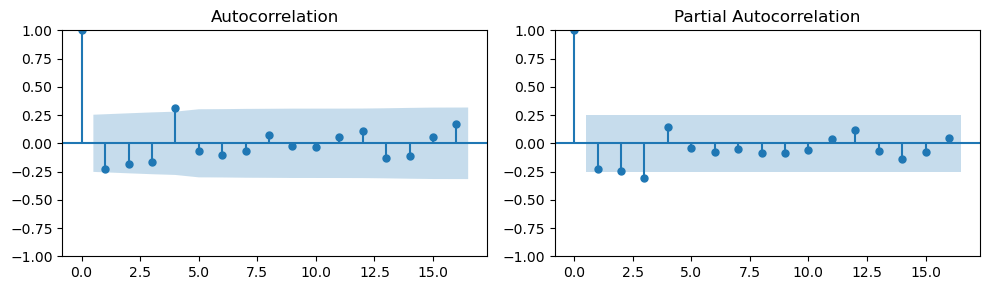

Ljung–Box Q(12) on ΔEPS (no df adjustment):
      lb_stat  lb_pvalue
12  16.659548   0.162859


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(dy, lags=16, ax=axes[0])
plot_pacf(dy, lags=16, ax=axes[1], method="ywm")
plt.tight_layout()
plt.show()

print("Ljung–Box Q(12) on ΔEPS (no df adjustment):")
print(acorr_ljungbox(dy, lags=[12], return_df=True))


**Model search and estimation.** Search SARIMA(p,d,q)(P,D,Q)₄ with **p+q+P+Q ≤ 6** (parsimony), **d,D ∈ {0,1}**, orders capped at 3. Among **converged** fits with **unadjusted** residual Q(12) p-value > 0.05, pick **minimum AIC**; refit that specification.

In [15]:
cand = []
for d, D in product([0, 1], repeat=2):
    for p, q, P, Q in product(range(0, 4), repeat=4):
        if p + q + P + Q == 0 or p + q + P + Q > 6:
            continue
        try:
            res = ARIMA(
                y, order=(p, d, q), seasonal_order=(P, D, Q, 4), trend="n"
            ).fit()
            if not res.mle_retvals.get("converged", True):
                continue
            lb = acorr_ljungbox(res.resid.dropna(), lags=[12], return_df=True)
            pv = float(lb["lb_pvalue"].iloc[0])
            cand.append(
                {
                    "order": (p, d, q),
                    "seasonal_order": (P, D, Q, 4),
                    "AIC": res.aic,
                    "Q12_p": pv,
                    "result": res,
                }
            )
        except Exception:
            pass

cand_df = pd.DataFrame(
    [{k: v for k, v in c.items() if k != "result"} for c in cand]
).sort_values("AIC")
accepted = [c for c in cand if c["Q12_p"] > 0.05]
accepted.sort(key=lambda x: x["AIC"])
best = accepted[0]
fit = best["result"]

print("Top candidate orders (first 10 by AIC among passing preliminary Q12):")
print(cand_df.head(10).to_string(index=False))
print("\nSelected:", best["order"], "x", best["seasonal_order"][:3], "period 4")
print(fit.summary())


Top candidate orders (first 10 by AIC among passing preliminary Q12):
    order seasonal_order        AIC    Q12_p
(1, 1, 1)   (1, 0, 0, 4) -94.340776 0.790353
(0, 1, 3)   (1, 0, 0, 4) -94.100175 0.723522
(1, 0, 0)   (1, 0, 0, 4) -93.998171 0.576137
(1, 0, 0)   (3, 0, 0, 4) -92.926660 0.728624
(1, 1, 2)   (1, 0, 0, 4) -92.721666 0.606253
(1, 1, 1)   (3, 0, 0, 4) -92.558699 0.823812
(2, 0, 0)   (1, 0, 0, 4) -92.406995 0.312697
(1, 1, 1)   (2, 0, 0, 4) -92.390247 0.820906
(1, 0, 1)   (1, 0, 0, 4) -92.289636 0.381867
(1, 1, 3)   (1, 0, 0, 4) -92.251892 0.680949

Selected: (1, 1, 1) x (1, 0, 0) period 4
                                    SARIMAX Results                                     
Dep. Variable:                              eps   No. Observations:                   61
Model:             ARIMA(1, 1, 1)x(1, 0, [], 4)   Log Likelihood                  51.170
Date:                          Thu, 09 Apr 2026   AIC                            -94.341
Time:                                

**Diagnostic: residual Q(12).** Ljung–Box at lag 12 with **model_df** = number of estimated AR/MA parameters (excluding σ²). **Adequacy** at 5%: p-value > 0.05 ⇒ no evidence of residual autocorrelation up to lag 12.

In [16]:
resid = fit.resid.dropna()
model_df = sum(1 for n in fit.param_names if n != "sigma2")
lb12 = acorr_ljungbox(resid, lags=[12], model_df=model_df, return_df=True)
print("model_df =", model_df)
print(lb12)

pval = float(lb12["lb_pvalue"].iloc[0])
stat = float(lb12["lb_stat"].iloc[0])
print(f"\nQ(12) = {stat:.4f}, p-value = {pval:.4g}")
if pval > 0.05:
    print("At 5%: residuals are consistent with white noise (model adequate w.r.t. this test).")
else:
    print("At 5%: reject white-noise null; consider richer dynamics.")


model_df = 3
     lb_stat  lb_pvalue
12  7.932889   0.540923

Q(12) = 7.9329, p-value = 0.5409
At 5%: residuals are consistent with white noise (model adequate w.r.t. this test).


**Fitted model (symbolic).** Let \(y_t\) denote EPS. With **statsmodels** signs, a compact form is
\[
(1 - \Phi_1 B^4)(1 - \phi_1 B)(1-B) y_t = (1 + \theta_1 B) a_t,
\]
using the estimated \(\phi_1, \theta_1, \Phi_1\) below (see also `fit.params`).

In [17]:
params = fit.params
print(params)
phi1 = params.get("ar.L1", np.nan)
theta1 = params.get("ma.L1", np.nan)
Phi1 = params.get("ar.S.L4", np.nan)
sig2 = params.get("sigma2", np.nan)
print(
    f"\n(1 - ({Phi1:.6f})B^4)(1 - ({phi1:.6f})B)(1-B) y_t = (1 + ({theta1:.6f})B) a_t,   Var(a_t) = {sig2:.6f}"
)


ar.L1      0.677776
ma.L1     -0.945927
ar.S.L4    0.700557
sigma2     0.010255
dtype: float64

(1 - (0.700557)B^4)(1 - (0.677776)B)(1-B) y_t = (1 + (-0.945927)B) a_t,   Var(a_t) = 0.010255


**Forecasts (1–4 steps ahead).** Predicted EPS for the next four quarters after **2006Q4** (last in-sample point).

In [18]:
fc = fit.get_forecast(steps=4)
out = pd.DataFrame(
    {
        "forecast_eps": fc.predicted_mean,
        "lower_95": fc.conf_int().iloc[:, 0],
        "upper_95": fc.conf_int().iloc[:, 1],
    }
)
out


,forecast_eps,lower_95,upper_95
2007-03-31 23:59:59.999999999,0.569538,0.371057,0.768018
2007-06-30 23:59:59.999999999,0.771034,0.525077,1.016991
2007-09-30 23:59:59.999999999,0.881527,0.612425,1.150630
2007-12-31 23:59:59.999999999,0.665297,0.383168,0.947426


**Summary.** EPS is modeled in **levels** because of negative values. The selected specification is **SARIMA(1,1,1)(1,0,0)₄** (lowest AIC among parsimonious candidates passing a preliminary residual Q(12) screen). The **adjusted Q(12)** on residuals is not significant at 5%, so the model is **adequate** for residual autocorrelation at that horizon. Point forecasts for 2007Q1–2007Q4 are in the table above.